In [15]:

!python3 -m pip install -U python-woc pandas matplotlib tqdm

Defaulting to user installation because normal site-packages is not writeable


In [16]:
from woc.remote import WocMapsRemote
from tqdm import tqdm
import pandas as pd
# creates the client
woc = WocMapsRemote( base_url="https://worldofcode.org/api/")
# if you got an API key
# woc = WocMapsRemote( base_url="https://worldofcode.org/api/", api_key="woc-XXXXXX-YYYYYY" )

# My 10 assigned WoC projects
projects = [
    "google-research_tensor2robot",
    "graphhopper_jsprit",
    "tdunning_t-digest",
    "villano-lab_nrsicap",
    "matthewheun_byname",
    "fabsig_gpboost",
    "hzwer_arxiv2020-rife",
    "lucmoreau_provtoolbox",
    "autodiff_autodiff",
    "mourner_rbush"
]

list_df_commits = []

for prj in projects:
    print("Getting commits for:", prj)

    commits = woc.get_values("p2c", prj)

    temp_df = pd.DataFrame(commits, columns=["sha1"])
    temp_df["project"] = prj

    list_df_commits.append(temp_df)

df = pd.concat(list_df_commits, ignore_index=True)

# Save so we do not have to retrieve these again
df.to_csv("df_commits.csv", index=False)

print("Total commits:", len(df))
print("Projects returned:", df["project"].nunique())

df.head()

Getting commits for: google-research_tensor2robot
Getting commits for: graphhopper_jsprit
Getting commits for: tdunning_t-digest
Getting commits for: villano-lab_nrsicap
Getting commits for: matthewheun_byname
Getting commits for: fabsig_gpboost
Getting commits for: hzwer_arxiv2020-rife
Getting commits for: lucmoreau_provtoolbox
Getting commits for: autodiff_autodiff
Getting commits for: mourner_rbush
Total commits: 13372
Projects returned: 10


,sha1,project
0,00a4e3109c8ee9c2702639019f620592a6aa9280,google-research_tensor2robot
1,010c934d5ecfbdfa8ae4b5bbca508586e0ff5d3d,google-research_tensor2robot
2,028301b84fe68740472967e12b534cebcb93f450,google-research_tensor2robot
3,02dc7a2ef295368280577b1255d32899a083b5e0,google-research_tensor2robot
4,03307a5ce18a906faf8dff6d1bbb2374edc1e26c,google-research_tensor2robot


In [17]:
print("Number of assigned projects:", len(projects))
print("Number of projects returned:", df["project"].nunique())

print("\nCommits per project:")
print(df.groupby("project").size())

missing = set(projects) - set(df["project"].unique())
print("\nMissing projects:", missing)

Number of assigned projects: 10
Number of projects returned: 10

Commits per project:
project
autodiff_autodiff               1139
fabsig_gpboost                  1256
google-research_tensor2robot     263
graphhopper_jsprit              2951
hzwer_arxiv2020-rife             925
lucmoreau_provtoolbox           3644
matthewheun_byname              1881
mourner_rbush                    409
tdunning_t-digest                581
villano-lab_nrsicap              323
dtype: int64

Missing projects: set()


In [18]:
# If the number of commits its not very large, you can try to get them all at the same time,
# The max batch size is 10
import time
# let us first split df['sha1'] in chunks
chunks = [df['sha1'][x:x+10] for x in range(0, len(df), 10)]
commit_data = []

for chunk in tqdm(chunks): # iterate over the commits
  # res, err = woc.show_content_many('commit',chunk.to_list())

  # commit.tch returns the same data but faster
  res, err = woc.get_values_many('commit.tch',chunk.to_list())
  res = {k: v[0] for k, v in res.items()}  # this conversion is necessary because of the internal implementation

  # to walk around the rate limit
  time.sleep(1)

  if err: # check for errors
    print('Got Errors', err)

  for commit_sha, commit in res.items():
    # flatten commit objects
    commit_data.append({
          'commit': commit_sha,
          'tree': commit[0],
          'parent': list(commit[1]),
          'author': commit[2][0],
          'author_time': int(commit[2][1]),
          'author_tz': commit[2][2],
          'committer': commit[3][0],
          'committer_time': int(commit[3][1]),
          'committer_tz': commit[3][2],
          'message': commit[4],
    })

df_commit_data = pd.DataFrame(commit_data)
df_commit_data = df_commit_data.merge(df, left_on='commit', right_on='sha1')
df_commit_data.to_csv('df_commit_data.csv', index=False)
df_commit_data.head(2)

  3%|██▍                                                                             | 41/1338 [00:42<22:06,  1.02s/it]

Got Errors {'0bea09152aad94b184cb9d3a1f3b44eefb49bc90': 'Key 0bea09152aad94b184cb9d3a1f3b44eefb49bc90 not found in /da5_fast/All.sha1c/commit_11.tch'}


  4%|███▏                                                                            | 54/1338 [00:55<21:53,  1.02s/it]

Got Errors {'18803ad0ee10e49782e8c017c6481967d64bf05b': 'Key 18803ad0ee10e49782e8c017c6481967d64bf05b not found in /da5_fast/All.sha1c/commit_24.tch'}


  6%|████▋                                                                           | 79/1338 [01:21<21:28,  1.02s/it]

...

Got Errors {'d282b2b32a396e78326e8a3ee21b92cc1e228c4c': 'Key d282b2b32a396e78326e8a3ee21b92cc1e228c4c not found in /da5_fast/All.sha1c/commit_82.tch'}


100%|█████████████████████████████████████████████████████████████████████████████▉| 1337/1338 [22:49<00:01,  1.02s/it]

Got Errors {'fbd509c8f76b73b939a911c1927a4b1c98b12b18': 'Key fbd509c8f76b73b939a911c1927a4b1c98b12b18 not found in /da5_fast/All.sha1c/commit_123.tch'}


100%|██████████████████████████████████████████████████████████████████████████████| 1338/1338 [22:50<00:00,  1.02s/it]


,commit,tree,parent,author,author_time,author_tz,committer,committer_time,committer_tz,message,sha1,project
0,00a4e3109c8ee9c2702639019f620592a6aa9280,ca7894eb679795be0346b330125c73cda538e728,[e65c101b730ad39fc60305eb3d2ab5d5512c6f9b],Tensor2Robot Team <tensor2robot-dev@google.com>,1606260662,-0800,Copybara-Service <copybara-worker@google.com>,1606260698,-0800,Allow predictors to sample from static checkpo...,00a4e3109c8ee9c2702639019f620592a6aa9280,google-research_tensor2robot
1,010c934d5ecfbdfa8ae4b5bbca508586e0ff5d3d,4409b181db88c52109dc8e2d7463fd2e4b1b37a9,[366d97e9d727da7bdc5735f9c5694d433686323a],Tensor2Robot Team <tensor2robot-dev@google.com>,1588007018,-0700,Copybara-Service <copybara-worker@google.com>,1588007052,-0700,Support uint16 in image decoding.\n\nPiperOrig...,010c934d5ecfbdfa8ae4b5bbca508586e0ff5d3d,google-research_tensor2robot


In [19]:
# what does the first record looks like?
# commit  parents
v = commit_data[0]
# commit tree, [parent{s}], [author, unixtime, tz ], [ committer, unixtime, tz ], Commit_message ]
print(v)

{'commit': '00a4e3109c8ee9c2702639019f620592a6aa9280', 'tree': 'ca7894eb679795be0346b330125c73cda538e728', 'parent': ['e65c101b730ad39fc60305eb3d2ab5d5512c6f9b'], 'author': 'Tensor2Robot Team <tensor2robot-dev@google.com>', 'author_time': 1606260662, 'author_tz': '-0800', 'committer': 'Copybara-Service <copybara-worker@google.com>', 'committer_time': 1606260698, 'committer_tz': '-0800', 'message': 'Allow predictors to sample from static checkpoint.\n\nPiperOrigin-RevId: 344142907\n'}


In [20]:
dfinf = df_commit_data[
    ['project', 'commit', 'author', 'author_time', 'message']
].copy()

dfinf.columns = [
    'project_wocid',
    'commit_sha1',
    'author',
    'time',
    'commit message'
]

dfinf.head()

,project_wocid,commit_sha1,author,time,commit message
0,google-research_tensor2robot,00a4e3109c8ee9c2702639019f620592a6aa9280,Tensor2Robot Team <tensor2robot-dev@google.com>,1606260662,Allow predictors to sample from static checkpo...
1,google-research_tensor2robot,010c934d5ecfbdfa8ae4b5bbca508586e0ff5d3d,Tensor2Robot Team <tensor2robot-dev@google.com>,1588007018,Support uint16 in image decoding.\n\nPiperOrig...
2,google-research_tensor2robot,028301b84fe68740472967e12b534cebcb93f450,Eric Jang <ejang@google.com>,1581106230,Fix broken vrgripper tests.\n\nPiperOrigin-Rev...
3,google-research_tensor2robot,02dc7a2ef295368280577b1255d32899a083b5e0,Tensor2Robot Team <tensor2robot-dev@google.com>,1622141775,Fixes two bugs in default_input_generator.Weig...
4,google-research_tensor2robot,03307a5ce18a906faf8dff6d1bbb2374edc1e26c,Yilei Yang <yileiyang@google.com>,1650047428,Remove unused comments related to Python 2 com...


In [21]:
netid = "cwolver1"

dfinf.to_csv(
    netid + "_project_summary.csv",
    index=False,
    sep=";"
)

print("Saved:", netid + "_project_summary.csv")

Saved: cwolver1_project_summary.csv


In [22]:
print("Total rows:", len(dfinf))
print("Number of projects:", dfinf["project_wocid"].nunique())

print("\nCommits per project:")
print(dfinf.groupby("project_wocid").size())

print("\nDuplicate project/commit rows:")
print(
    dfinf.duplicated(
        subset=["project_wocid", "commit_sha1"]
    ).sum()
)

Total rows: 13295
Number of projects: 10

Commits per project:
project_wocid
autodiff_autodiff               1138
fabsig_gpboost                  1256
google-research_tensor2robot     263
graphhopper_jsprit              2925
hzwer_arxiv2020-rife             925
lucmoreau_provtoolbox           3620
matthewheun_byname              1881
mourner_rbush                    394
tdunning_t-digest                570
villano-lab_nrsicap              323
dtype: int64

Duplicate project/commit rows:
0


In [23]:
woc_stats = (
    dfinf.groupby("project_wocid")
    .agg(
        commits=("commit_sha1", "nunique"),
        authors=("author", "nunique"),
        min_time=("time", "min"),
        max_time=("time", "max")
    )
    .reset_index()
)

woc_stats

,project_wocid,commits,authors,min_time,max_time
0,autodiff_autodiff,1138,70,1531464195,1758747679
1,fabsig_gpboost,1256,17,1585927023,1762259041
2,google-research_tensor2robot,263,25,1547578657,1727687675
3,graphhopper_jsprit,2925,116,1370334347,1761274703
4,hzwer_arxiv2020-rife,925,35,1605159985,1757485923
5,lucmoreau_provtoolbox,3620,33,1314718980,1762536328
6,matthewheun_byname,1881,5,1485710627,1752103929
7,mourner_rbush,394,40,1372862539,1732655528
8,tdunning_t-digest,570,74,1384819635,1744611565
9,villano-lab_nrsicap,323,11,1570638847,1723756861


In [24]:
woc_stats["min_date"] = pd.to_datetime(
    woc_stats["min_time"],
    unit="s"
)

woc_stats["max_date"] = pd.to_datetime(
    woc_stats["max_time"],
    unit="s"
)

woc_stats

,project_wocid,commits,authors,min_time,max_time,min_date,max_date
0,autodiff_autodiff,1138,70,1531464195,1758747679,2018-07-13 06:43:15,2025-09-24 21:01:19
1,fabsig_gpboost,1256,17,1585927023,1762259041,2020-04-03 15:17:03,2025-11-04 12:24:01
2,google-research_tensor2robot,263,25,1547578657,1727687675,2019-01-15 18:57:37,2024-09-30 09:14:35
3,graphhopper_jsprit,2925,116,1370334347,1761274703,2013-06-04 08:25:47,2025-10-24 02:58:23
4,hzwer_arxiv2020-rife,925,35,1605159985,1757485923,2020-11-12 05:46:25,2025-09-10 06:32:03
5,lucmoreau_provtoolbox,3620,33,1314718980,1762536328,2011-08-30 15:43:00,2025-11-07 17:25:28
6,matthewheun_byname,1881,5,1485710627,1752103929,2017-01-29 17:23:47,2025-07-09 23:32:09
7,mourner_rbush,394,40,1372862539,1732655528,2013-07-03 14:42:19,2024-11-26 21:12:08
8,tdunning_t-digest,570,74,1384819635,1744611565,2013-11-19 00:07:15,2025-04-14 06:19:25
9,villano-lab_nrsicap,323,11,1570638847,1723756861,2019-10-09 16:34:07,2024-08-15 21:21:01


In [25]:
github_data = pd.DataFrame([
    ["google-research_tensor2robot", 564, 117, "2024-08-19"],
    ["graphhopper_jsprit", 1800, 642, "2026-09-14"],
    ["tdunning_t-digest", 2200, 232, "2025-02-17"],
    ["villano-lab_nrsicap", 1, 0, "2024-08-15"],
    ["matthewheun_byname", 2, 0, "2026-09-26"],
    ["fabsig_gpboost", 699, 56, "2026-09-28"],
    ["hzwer_arxiv2020-rife", 5600, 570, "2025-09-10"],
    ["lucmoreau_provtoolbox", 83, 43, "2026-07-28"],
    ["autodiff_autodiff", 2000, 196, "2025-01-27"],
    ["mourner_rbush", 2800, 254, "2026-04-03"]
], columns=[
    "project_wocid",
    "stars",
    "forks",
    "last_github_commit"
])

github_data

,project_wocid,stars,forks,last_github_commit
0,google-research_tensor2robot,564,117,2024-08-19
1,graphhopper_jsprit,1800,642,2026-09-14
2,tdunning_t-digest,2200,232,2025-02-17
3,villano-lab_nrsicap,1,0,2024-08-15
4,matthewheun_byname,2,0,2026-09-26
5,fabsig_gpboost,699,56,2026-09-28
6,hzwer_arxiv2020-rife,5600,570,2025-09-10
7,lucmoreau_provtoolbox,83,43,2026-07-28
8,autodiff_autodiff,2000,196,2025-01-27
9,mourner_rbush,2800,254,2026-04-03


In [26]:
part1_stats = woc_stats.merge(
    github_data,
    on="project_wocid",
    how="left"
)

part1_stats

,project_wocid,commits,authors,min_time,max_time,min_date,max_date,stars,forks,last_github_commit
0,autodiff_autodiff,1138,70,1531464195,1758747679,2018-07-13 06:43:15,2025-09-24 21:01:19,2000,196,2025-01-27
1,fabsig_gpboost,1256,17,1585927023,1762259041,2020-04-03 15:17:03,2025-11-04 12:24:01,699,56,2026-09-28
2,google-research_tensor2robot,263,25,1547578657,1727687675,2019-01-15 18:57:37,2024-09-30 09:14:35,564,117,2024-08-19
3,graphhopper_jsprit,2925,116,1370334347,1761274703,2013-06-04 08:25:47,2025-10-24 02:58:23,1800,642,2026-09-14
4,hzwer_arxiv2020-rife,925,35,1605159985,1757485923,2020-11-12 05:46:25,2025-09-10 06:32:03,5600,570,2025-09-10
5,lucmoreau_provtoolbox,3620,33,1314718980,1762536328,2011-08-30 15:43:00,2025-11-07 17:25:28,83,43,2026-07-28
6,matthewheun_byname,1881,5,1485710627,1752103929,2017-01-29 17:23:47,2025-07-09 23:32:09,2,0,2026-09-26
7,mourner_rbush,394,40,1372862539,1732655528,2013-07-03 14:42:19,2024-11-26 21:12:08,2800,254,2026-04-03
8,tdunning_t-digest,570,74,1384819635,1744611565,2013-11-19 00:07:15,2025-04-14 06:19:25,2200,232,2025-02-17
9,villano-lab_nrsicap,323,11,1570638847,1723756861,2019-10-09 16:34:07,2024-08-15 21:21:01,1,0,2024-08-15


# Part 2 - Data Visualization

This section groups commit activity by month for each assigned project,
fills inactive months with zero commits, creates time-series plots, and
calculates inactivity-gap statistics.

In [27]:
import pandas as pd
import matplotlib.pyplot as plt

summary = pd.read_csv(
    "cwolver1_project_summary.csv",
    sep=";"
)

print("Rows:", len(summary))
print("Projects:", summary["project_wocid"].nunique())

summary.head()

Rows: 13295
Projects: 10


,project_wocid,commit_sha1,author,time,commit message
0,google-research_tensor2robot,00a4e3109c8ee9c2702639019f620592a6aa9280,Tensor2Robot Team <tensor2robot-dev@google.com>,1606260662,Allow predictors to sample from static checkpo...
1,google-research_tensor2robot,010c934d5ecfbdfa8ae4b5bbca508586e0ff5d3d,Tensor2Robot Team <tensor2robot-dev@google.com>,1588007018,Support uint16 in image decoding.\n\nPiperOrig...
2,google-research_tensor2robot,028301b84fe68740472967e12b534cebcb93f450,Eric Jang <ejang@google.com>,1581106230,Fix broken vrgripper tests.\n\nPiperOrigin-Rev...
3,google-research_tensor2robot,02dc7a2ef295368280577b1255d32899a083b5e0,Tensor2Robot Team <tensor2robot-dev@google.com>,1622141775,Fixes two bugs in default_input_generator.Weig...
4,google-research_tensor2robot,03307a5ce18a906faf8dff6d1bbb2374edc1e26c,Yilei Yang <yileiyang@google.com>,1650047428,Remove unused comments related to Python 2 com...


In [28]:
# Convert Unix timestamps to dates
summary["Date"] = pd.to_datetime(summary["time"], unit="s")

# Extract 
summary["Month"] = summary["Date"].dt.strftime("%Y-%m")

summary[
    ["project_wocid", "time", "Date", "Month"]
].head()

,project_wocid,time,Date,Month
0,google-research_tensor2robot,1606260662,2020-11-24 23:31:02,2020-11
1,google-research_tensor2robot,1588007018,2020-04-27 17:03:38,2020-04
2,google-research_tensor2robot,1581106230,2020-02-07 20:10:30,2020-02
3,google-research_tensor2robot,1622141775,2021-05-27 18:56:15,2021-05
4,google-research_tensor2robot,1650047428,2022-04-15 18:30:28,2022-04


In [29]:
all_timeseries = []

for project in sorted(summary["project_wocid"].unique()):

    # Select commits belonging to this project
    project_df = summary[
        summary["project_wocid"] == project
    ].copy()

    # Count commits in each month
    monthly = (
        project_df.groupby("Month")
        .size()
        .reset_index(name="#Commits")
    )

    # Convert Month into datetime temporarily
    monthly["MonthDate"] = pd.to_datetime(
        monthly["Month"],
        format="%Y-%m"
    )

    # Create every month from first commit to last commit
    full_range = pd.date_range(
        start=monthly["MonthDate"].min(),
        end=monthly["MonthDate"].max(),
        freq="MS"
    )

    complete = pd.DataFrame({
        "MonthDate": full_range
    })

    # Add existing commit counts
    complete = complete.merge(
        monthly[["MonthDate", "#Commits"]],
        on="MonthDate",
        how="left"
    )

    # Months with no commits become zero
    complete["#Commits"] = (
        complete["#Commits"]
        .fillna(0)
        .astype(int)
    )

    # Return to YYYY-MM
    complete["Month"] = (
        complete["MonthDate"]
        .dt.strftime("%Y-%m")
    )

    # Add project so we can distinguish projects
    complete["project"] = project

    all_timeseries.append(
        complete[["project", "Month", "#Commits"]]
    )

timeseries = pd.concat(
    all_timeseries,
    ignore_index=True
)

timeseries.head(20)

,project,Month,#Commits
0,autodiff_autodiff,2018-07,52
1,autodiff_autodiff,2018-08,21
2,autodiff_autodiff,2018-09,0
3,autodiff_autodiff,2018-10,0
4,autodiff_autodiff,2018-11,0
5,autodiff_autodiff,2018-12,0
6,autodiff_autodiff,2019-01,6
7,autodiff_autodiff,2019-02,100
8,autodiff_autodiff,2019-03,2
9,autodiff_autodiff,2019-04,0


In [30]:
netid = "cwolver1"

for project in sorted(timeseries["project"].unique()):

    project_ts = timeseries[
        timeseries["project"] == project
    ][["Month", "#Commits"]]

    filename = (
        netid +
        "_commits_timeseries_" +
        project +
        ".csv"
    )

    project_ts.to_csv(
        filename,
        sep=";",
        index=False
    )

    print("Saved:", filename)

Saved: cwolver1_commits_timeseries_autodiff_autodiff.csv
Saved: cwolver1_commits_timeseries_fabsig_gpboost.csv
Saved: cwolver1_commits_timeseries_google-research_tensor2robot.csv
Saved: cwolver1_commits_timeseries_graphhopper_jsprit.csv
Saved: cwolver1_commits_timeseries_hzwer_arxiv2020-rife.csv
Saved: cwolver1_commits_timeseries_lucmoreau_provtoolbox.csv
Saved: cwolver1_commits_timeseries_matthewheun_byname.csv
Saved: cwolver1_commits_timeseries_mourner_rbush.csv
Saved: cwolver1_commits_timeseries_tdunning_t-digest.csv
Saved: cwolver1_commits_timeseries_villano-lab_nrsicap.csv


In [31]:
print("Total months:", len(timeseries))
print(
    "Zero-commit months:",
    (timeseries["#Commits"] == 0).sum()
)

timeseries[
    timeseries["#Commits"] == 0
].head(20)

Total months: 1041
Zero-commit months: 309


,project,Month,#Commits
2,autodiff_autodiff,2018-09,0
3,autodiff_autodiff,2018-10,0
4,autodiff_autodiff,2018-11,0
5,autodiff_autodiff,2018-12,0
9,autodiff_autodiff,2019-04,0
21,autodiff_autodiff,2020-04,0
24,autodiff_autodiff,2020-07,0
31,autodiff_autodiff,2021-02,0
41,autodiff_autodiff,2021-12,0
54,autodiff_autodiff,2023-01,0


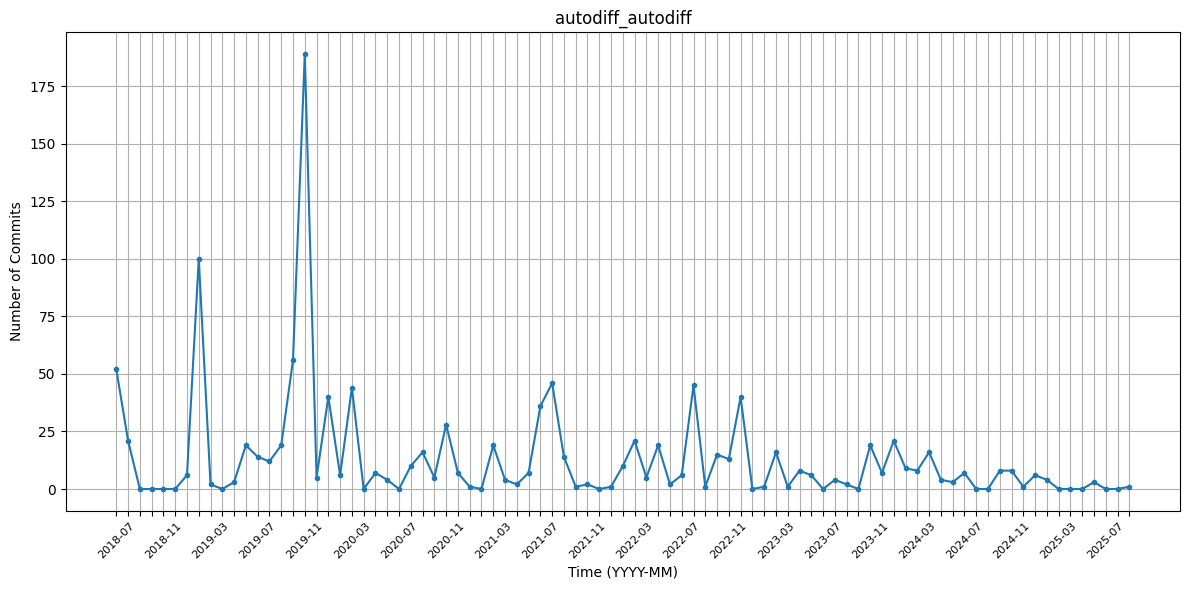

Saved: cwolver1_timeseries_autodiff_autodiff.png


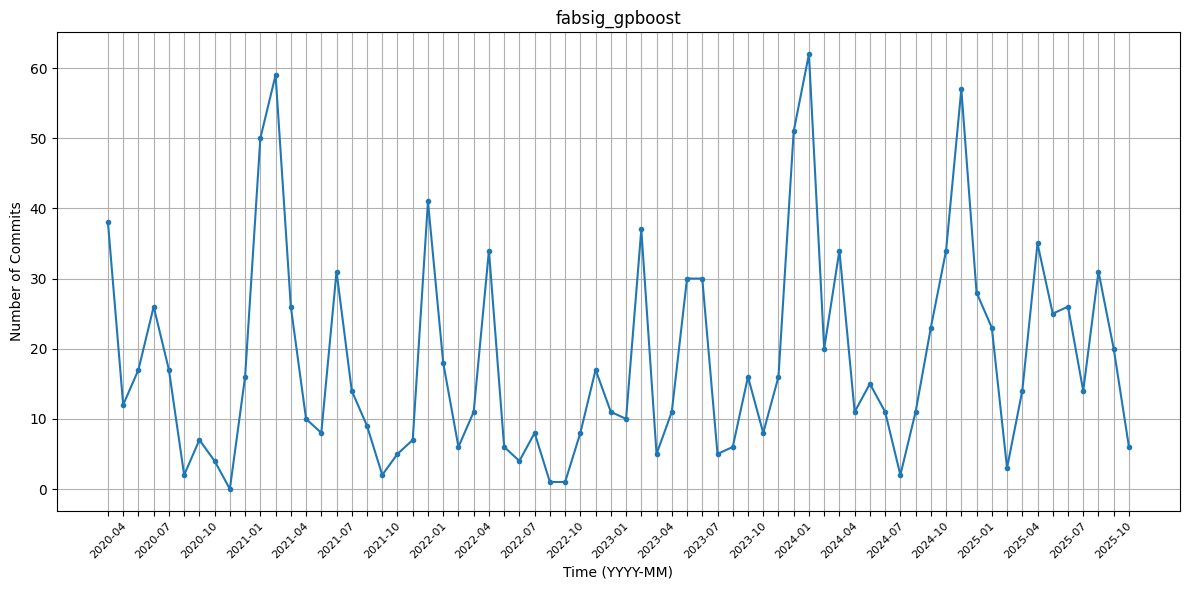

Saved: cwolver1_timeseries_fabsig_gpboost.png


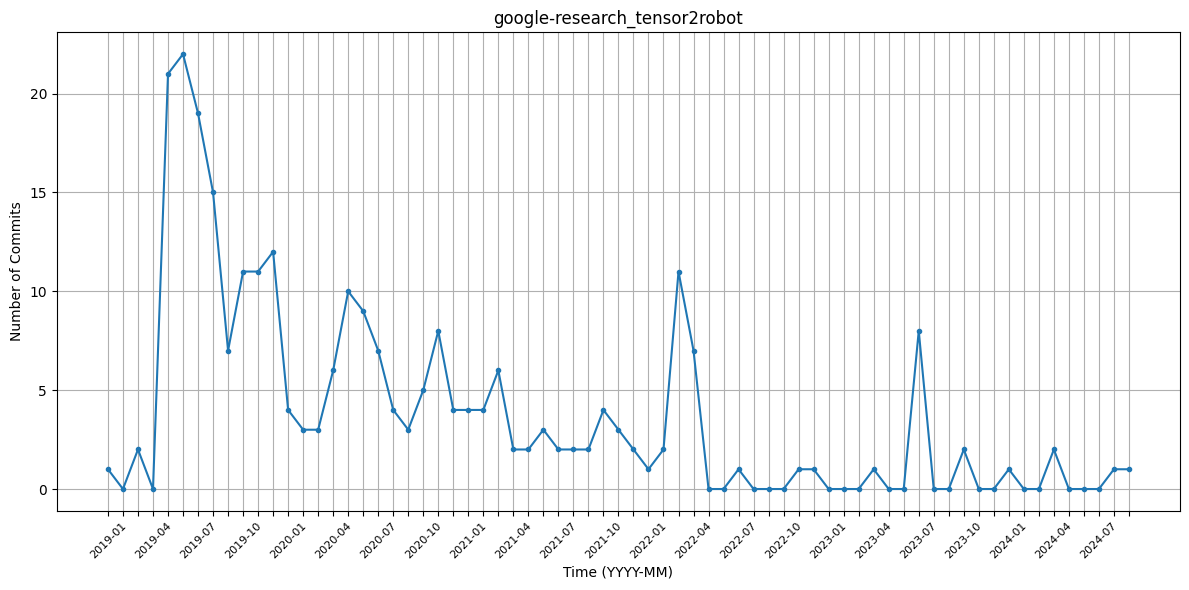

Saved: cwolver1_timeseries_google-research_tensor2robot.png


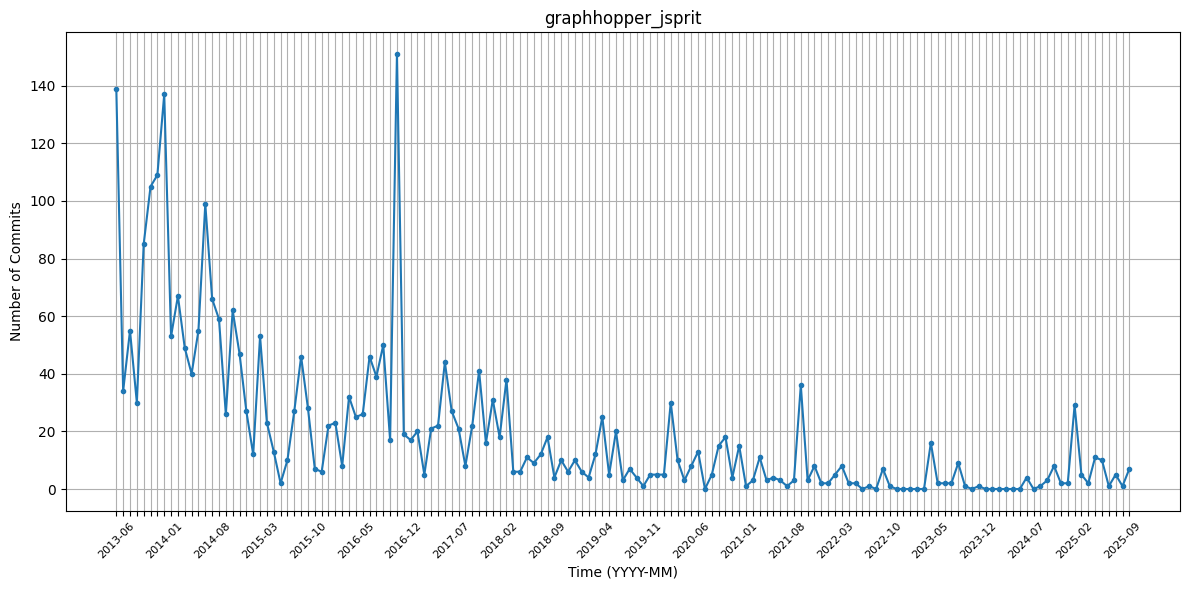

Saved: cwolver1_timeseries_graphhopper_jsprit.png


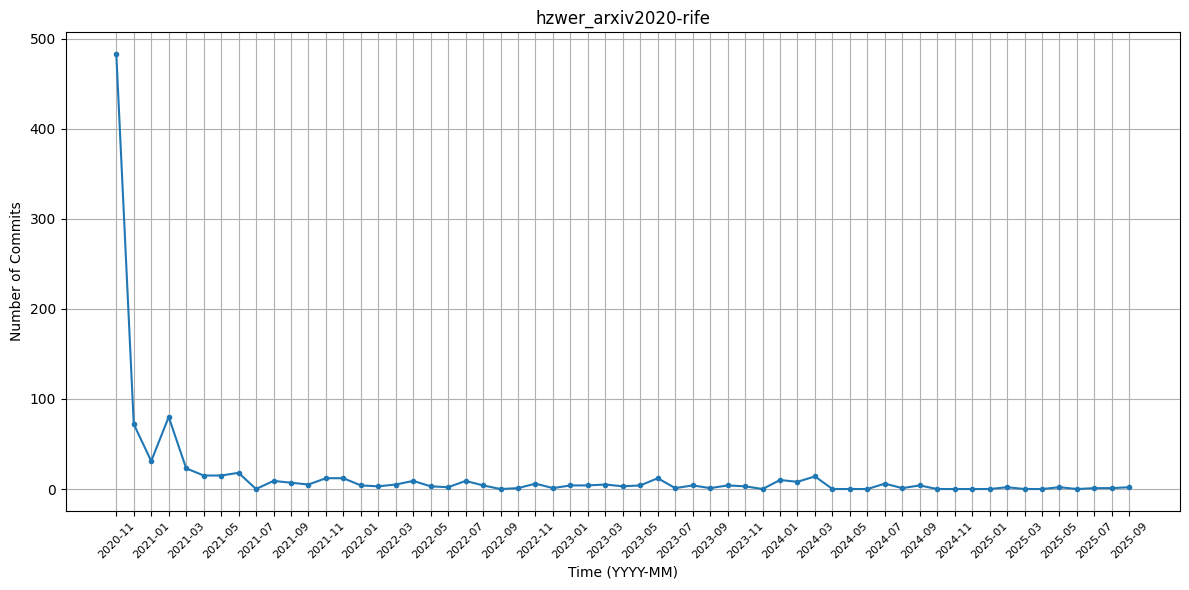

Saved: cwolver1_timeseries_hzwer_arxiv2020-rife.png


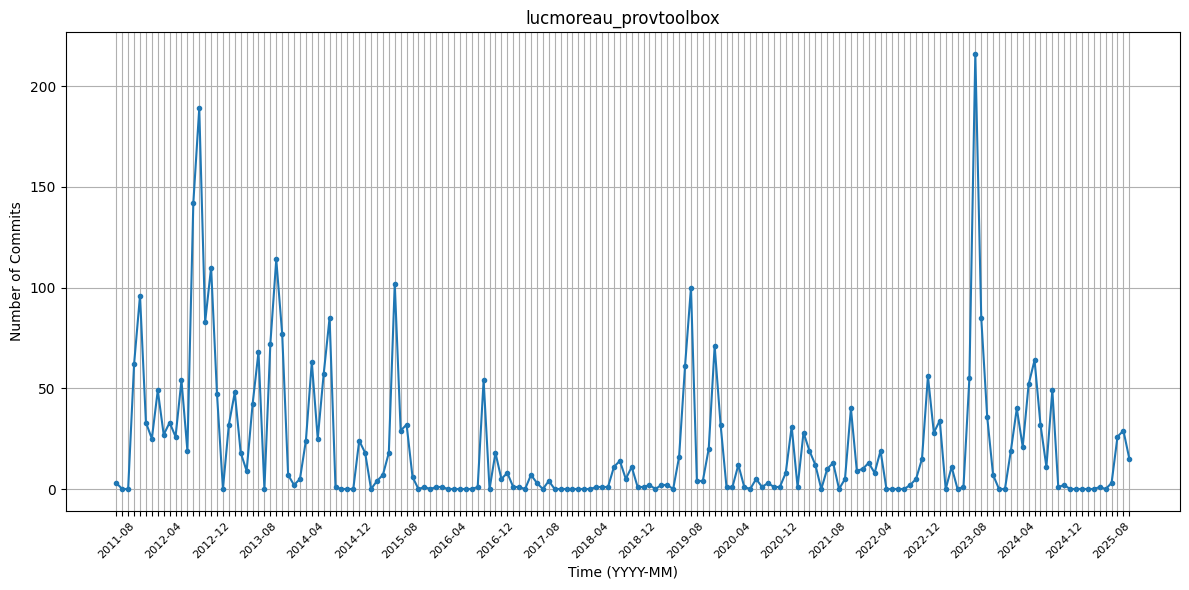

Saved: cwolver1_timeseries_lucmoreau_provtoolbox.png


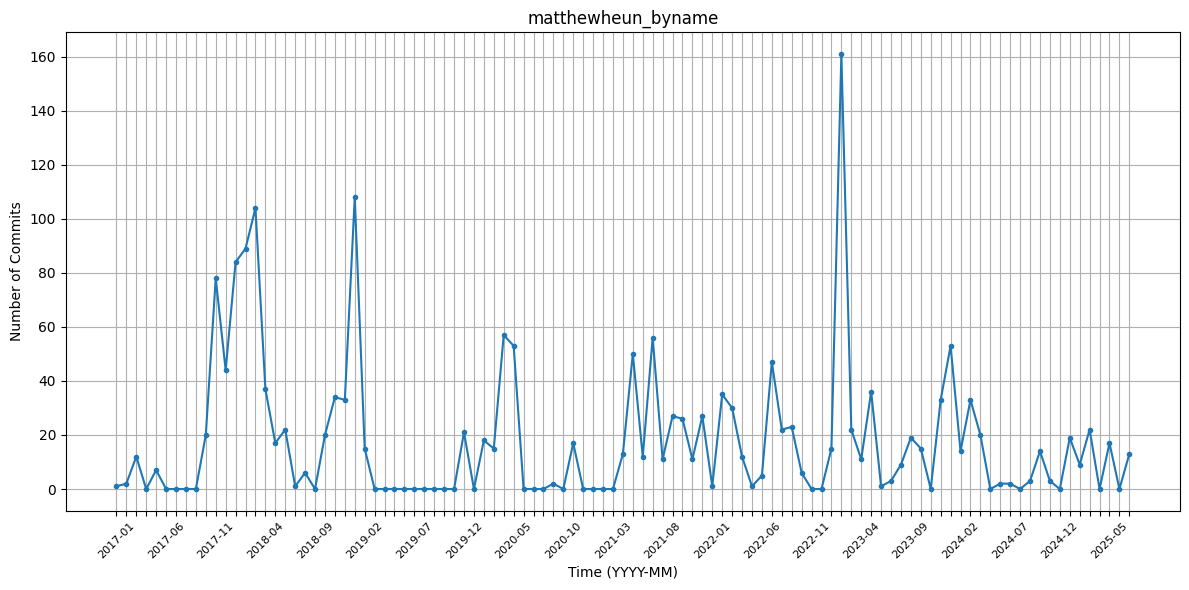

Saved: cwolver1_timeseries_matthewheun_byname.png


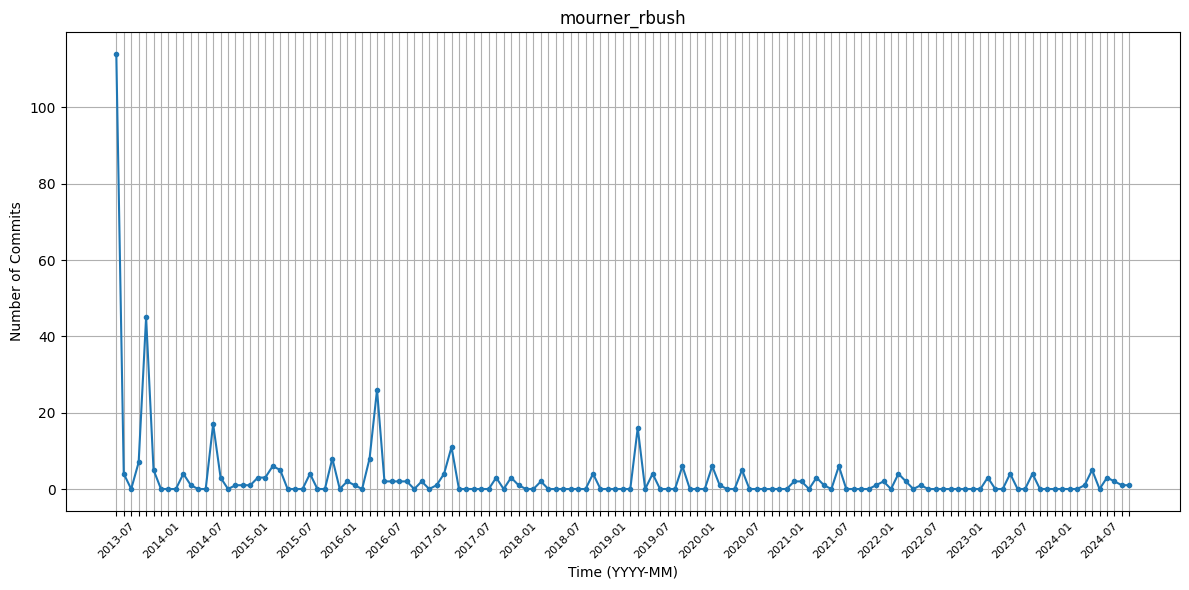

Saved: cwolver1_timeseries_mourner_rbush.png


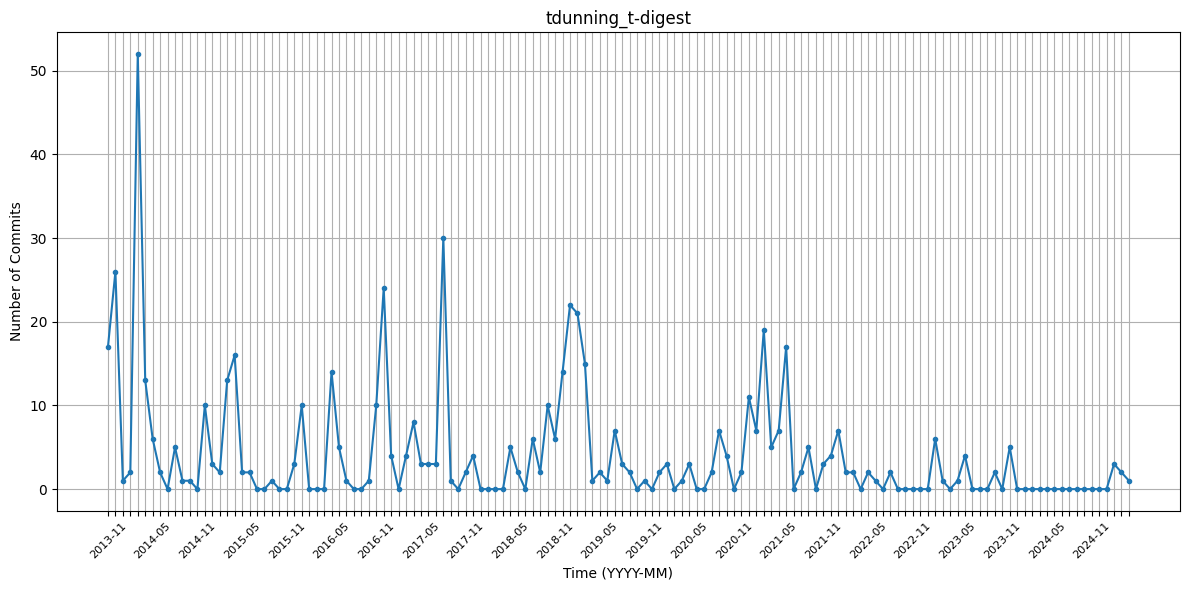

Saved: cwolver1_timeseries_tdunning_t-digest.png


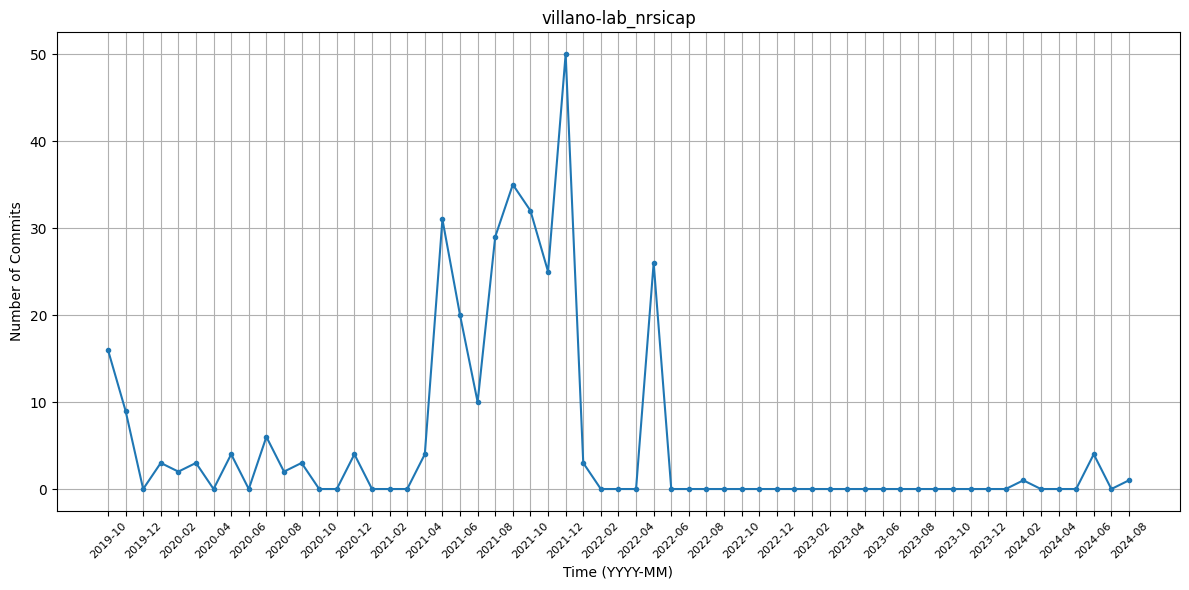

Saved: cwolver1_timeseries_villano-lab_nrsicap.png


In [32]:
for project in sorted(timeseries["project"].unique()):

    project_ts = timeseries[
        timeseries["project"] == project
    ].copy()

    plt.figure(figsize=(12, 6))

    plt.plot(
        project_ts["Month"],
        project_ts["#Commits"],
        marker="o",
        linestyle="-",
        markersize=3
    )

    plt.xlabel("Time (YYYY-MM)")
    plt.ylabel("Number of Commits")
    plt.title(project)
    plt.grid(True)

    # Show fewer x-axis labels so long timelines remain readable
    ax = plt.gca()

    step = max(1, len(project_ts) // 20)

    for i, label in enumerate(ax.get_xticklabels()):
        if i % step != 0:
            label.set_visible(False)

    plt.xticks(rotation=45, fontsize=8)
    plt.tight_layout()

    filename = (
        netid +
        "_timeseries_" +
        project +
        ".png"
    )

    plt.savefig(
        filename,
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()
    plt.close()

    print("Saved:", filename)

In [33]:
def analyze_gaps(project_ts):

    project_ts = project_ts.reset_index(drop=True)

    gaps = []
    current_start = None
    current_length = 0

    for i, row in project_ts.iterrows():

        if row["#Commits"] == 0:

            if current_start is None:
                current_start = i

            current_length += 1

        else:

            if current_start is not None:
                gaps.append({
                    "start_index": current_start,
                    "end_index": i - 1,
                    "length": current_length
                })

                current_start = None
                current_length = 0

    # Handle a gap that reaches the end of the timeline
    if current_start is not None:
        gaps.append({
            "start_index": current_start,
            "end_index": len(project_ts) - 1,
            "length": current_length
        })

    # If there are no gaps
    if len(gaps) == 0:
        return {
            "LongestGapStart": "",
            "LongestGapEnd": "",
            "LongestGapLength": 0,
            "NumCommitsAfterLastGap": 0,
            "NumberOfGapsInTimeline": 0
        }

    # Find longest zero-commit period
    longest_gap = max(
        gaps,
        key=lambda x: x["length"]
    )

    start_index = longest_gap["start_index"]
    end_index = longest_gap["end_index"]

    gap_start = project_ts.loc[
        start_index,
        "Month"
    ]

    gap_end = project_ts.loc[
        end_index,
        "Month"
    ]

    # Commits after the end of the longest gap
    commits_after = project_ts.loc[
        end_index + 1:,
        "#Commits"
    ].sum()

    # Count gaps that lasted at least 3 months
    gaps_at_least_three = sum(
        1 for gap in gaps
        if gap["length"] >= 3
    )

    return {
        "LongestGapStart": gap_start,
        "LongestGapEnd": gap_end,
        "LongestGapLength": longest_gap["length"],
        "NumCommitsAfterLastGap": int(commits_after),
        "NumberOfGapsInTimeline": gaps_at_least_three
    }

In [34]:
gap_results = []

for project in sorted(timeseries["project"].unique()):

    project_ts = (
        timeseries[
            timeseries["project"] == project
        ]
        .reset_index(drop=True)
    )

    result = analyze_gaps(project_ts)

    result["project"] = project

    gap_results.append(result)

gap_stats = pd.DataFrame(gap_results)

gap_stats = gap_stats[
    [
        "project",
        "LongestGapStart",
        "LongestGapEnd",
        "LongestGapLength",
        "NumCommitsAfterLastGap",
        "NumberOfGapsInTimeline"
    ]
]

gap_stats

,project,LongestGapStart,LongestGapEnd,LongestGapLength,NumCommitsAfterLastGap,NumberOfGapsInTimeline
0,autodiff_autodiff,2018-09,2018-12,4,1065,2
1,fabsig_gpboost,2020-12,2020-12,1,1133,0
2,google-research_tensor2robot,2022-08,2022-10,3,18,3
3,graphhopper_jsprit,2024-01,2024-06,6,91,2
4,hzwer_arxiv2020-rife,2024-10,2025-01,4,8,2
5,lucmoreau_provtoolbox,2017-10,2018-04,7,1528,5
6,matthewheun_byname,2019-03,2019-11,9,1147,4
7,mourner_rbush,2022-08,2023-03,8,24,11
8,tdunning_t-digest,2024-01,2025-01,13,6,5
9,villano-lab_nrsicap,2022-06,2024-01,20,6,4


In [35]:
woc_stats = (
    summary.groupby("project_wocid")
    .agg(
        commits=("commit_sha1", "nunique"),
        authors=("author", "nunique"),
        min_time=("time", "min"),
        max_time=("time", "max")
    )
    .reset_index()
)

# Add readable dates
woc_stats["min_date"] = pd.to_datetime(
    woc_stats["min_time"],
    unit="s"
)

woc_stats["max_date"] = pd.to_datetime(
    woc_stats["max_time"],
    unit="s"
)

woc_stats

,project_wocid,commits,authors,min_time,max_time,min_date,max_date
0,autodiff_autodiff,1138,70,1531464195,1758747679,2018-07-13 06:43:15,2025-09-24 21:01:19
1,fabsig_gpboost,1256,17,1585927023,1762259041,2020-04-03 15:17:03,2025-11-04 12:24:01
2,google-research_tensor2robot,263,25,1547578657,1727687675,2019-01-15 18:57:37,2024-09-30 09:14:35
3,graphhopper_jsprit,2925,116,1370334347,1761274703,2013-06-04 08:25:47,2025-10-24 02:58:23
4,hzwer_arxiv2020-rife,925,35,1605159985,1757485923,2020-11-12 05:46:25,2025-09-10 06:32:03
5,lucmoreau_provtoolbox,3620,33,1314718980,1762536328,2011-08-30 15:43:00,2025-11-07 17:25:28
6,matthewheun_byname,1881,5,1485710627,1752103929,2017-01-29 17:23:47,2025-07-09 23:32:09
7,mourner_rbush,394,40,1372862539,1732655528,2013-07-03 14:42:19,2024-11-26 21:12:08
8,tdunning_t-digest,570,74,1384819635,1744611565,2013-11-19 00:07:15,2025-04-14 06:19:25
9,villano-lab_nrsicap,323,11,1570638847,1723756861,2019-10-09 16:34:07,2024-08-15 21:21:01


In [36]:
project_stats = (
    woc_stats
    .merge(
        github_data,
        on="project_wocid",
        how="left"
    )
)

project_stats = project_stats.merge(
    gap_stats,
    left_on="project_wocid",
    right_on="project",
    how="left"
)

project_stats.head()

,project_wocid,commits,authors,min_time,max_time,min_date,max_date,stars,forks,last_github_commit,project,LongestGapStart,LongestGapEnd,LongestGapLength,NumCommitsAfterLastGap,NumberOfGapsInTimeline
0,autodiff_autodiff,1138,70,1531464195,1758747679,2018-07-13 06:43:15,2025-09-24 21:01:19,2000,196,2025-01-27,autodiff_autodiff,2018-09,2018-12,4,1065,2
1,fabsig_gpboost,1256,17,1585927023,1762259041,2020-04-03 15:17:03,2025-11-04 12:24:01,699,56,2026-09-28,fabsig_gpboost,2020-12,2020-12,1,1133,0
2,google-research_tensor2robot,263,25,1547578657,1727687675,2019-01-15 18:57:37,2024-09-30 09:14:35,564,117,2024-08-19,google-research_tensor2robot,2022-08,2022-10,3,18,3
3,graphhopper_jsprit,2925,116,1370334347,1761274703,2013-06-04 08:25:47,2025-10-24 02:58:23,1800,642,2026-09-14,graphhopper_jsprit,2024-01,2024-06,6,91,2
4,hzwer_arxiv2020-rife,925,35,1605159985,1757485923,2020-11-12 05:46:25,2025-09-10 06:32:03,5600,570,2025-09-10,hzwer_arxiv2020-rife,2024-10,2025-01,4,8,2


In [37]:
project_stats[
    [
        "project_wocid",
        "commits",
        "authors",
        "min_date",
        "max_date",
        "LongestGapStart",
        "LongestGapEnd",
        "LongestGapLength",
        "NumCommitsAfterLastGap",
        "NumberOfGapsInTimeline"
    ]
]

,project_wocid,commits,authors,min_date,max_date,LongestGapStart,LongestGapEnd,LongestGapLength,NumCommitsAfterLastGap,NumberOfGapsInTimeline
0,autodiff_autodiff,1138,70,2018-07-13 06:43:15,2025-09-24 21:01:19,2018-09,2018-12,4,1065,2
1,fabsig_gpboost,1256,17,2020-04-03 15:17:03,2025-11-04 12:24:01,2020-12,2020-12,1,1133,0
2,google-research_tensor2robot,263,25,2019-01-15 18:57:37,2024-09-30 09:14:35,2022-08,2022-10,3,18,3
3,graphhopper_jsprit,2925,116,2013-06-04 08:25:47,2025-10-24 02:58:23,2024-01,2024-06,6,91,2
4,hzwer_arxiv2020-rife,925,35,2020-11-12 05:46:25,2025-09-10 06:32:03,2024-10,2025-01,4,8,2
5,lucmoreau_provtoolbox,3620,33,2011-08-30 15:43:00,2025-11-07 17:25:28,2017-10,2018-04,7,1528,5
6,matthewheun_byname,1881,5,2017-01-29 17:23:47,2025-07-09 23:32:09,2019-03,2019-11,9,1147,4
7,mourner_rbush,394,40,2013-07-03 14:42:19,2024-11-26 21:12:08,2022-08,2023-03,8,24,11
8,tdunning_t-digest,570,74,2013-11-19 00:07:15,2025-04-14 06:19:25,2024-01,2025-01,13,6,5
9,villano-lab_nrsicap,323,11,2019-10-09 16:34:07,2024-08-15 21:21:01,2022-06,2024-01,20,6,4


In [38]:
activity_patterns = {
    "google-research_tensor2robot": "declining",
    "graphhopper_jsprit": "declining",
    "tdunning_t-digest": "declining",
    "villano-lab_nrsicap": "irregular",
    "matthewheun_byname": "irregular",
    "fabsig_gpboost": "irregular",
    "hzwer_arxiv2020-rife": "declining",
    "lucmoreau_provtoolbox": "irregular",
    "autodiff_autodiff": "declining",
    "mourner_rbush": "declining"
}

activity_patterns

{'google-research_tensor2robot': 'declining',
 'graphhopper_jsprit': 'declining',
 'tdunning_t-digest': 'declining',
 'villano-lab_nrsicap': 'irregular',
 'matthewheun_byname': 'irregular',
 'fabsig_gpboost': 'irregular',
 'hzwer_arxiv2020-rife': 'declining',
 'lucmoreau_provtoolbox': 'irregular',
 'autodiff_autodiff': 'declining',
 'mourner_rbush': 'declining'}

In [39]:
project_stats["ActivityPattern"] = (
    project_stats["project_wocid"]
    .map(activity_patterns)
)

In [40]:
final_stats = project_stats[
    [
        "project_wocid",
        "commits",
        "authors",
        "max_time",
        "min_time",
        "stars",
        "forks",
        "last_github_commit",
        "LongestGapStart",
        "LongestGapEnd",
        "LongestGapLength",
        "NumCommitsAfterLastGap",
        "NumberOfGapsInTimeline",
        "ActivityPattern"
    ]
].copy()

final_stats.columns = [
    "project",
    "#commits",
    "#authors",
    "max time",
    "min time",
    "#stars",
    "#forks",
    "LastGHCommitDate",
    "LongestGapStart (YYYY-MM)",
    "LongestGapEnd (YYYY-MM)",
    "LongestGapLength",
    "NumCommitsAfterLastGap",
    "NumberOfGapsInTimeline",
    "ActivityPattern"
]

final_stats

,project,#commits,#authors,max time,min time,#stars,#forks,LastGHCommitDate,LongestGapStart (YYYY-MM),LongestGapEnd (YYYY-MM),LongestGapLength,NumCommitsAfterLastGap,NumberOfGapsInTimeline,ActivityPattern
0,autodiff_autodiff,1138,70,1758747679,1531464195,2000,196,2025-01-27,2018-09,2018-12,4,1065,2,declining
1,fabsig_gpboost,1256,17,1762259041,1585927023,699,56,2026-09-28,2020-12,2020-12,1,1133,0,irregular
2,google-research_tensor2robot,263,25,1727687675,1547578657,564,117,2024-08-19,2022-08,2022-10,3,18,3,declining
3,graphhopper_jsprit,2925,116,1761274703,1370334347,1800,642,2026-09-14,2024-01,2024-06,6,91,2,declining
4,hzwer_arxiv2020-rife,925,35,1757485923,1605159985,5600,570,2025-09-10,2024-10,2025-01,4,8,2,declining
5,lucmoreau_provtoolbox,3620,33,1762536328,1314718980,83,43,2026-07-28,2017-10,2018-04,7,1528,5,irregular
6,matthewheun_byname,1881,5,1752103929,1485710627,2,0,2026-09-26,2019-03,2019-11,9,1147,4,irregular
7,mourner_rbush,394,40,1732655528,1372862539,2800,254,2026-04-03,2022-08,2023-03,8,24,11,declining
8,tdunning_t-digest,570,74,1744611565,1384819635,2200,232,2025-02-17,2024-01,2025-01,13,6,5,declining
9,villano-lab_nrsicap,323,11,1723756861,1570638847,1,0,2024-08-15,2022-06,2024-01,20,6,4,irregular


In [41]:
final_stats.to_csv(
    "cwolver1_project_stats.csv",
    sep=";",
    index=False
)

print("Saved: cwolver1_project_stats.csv")

Saved: cwolver1_project_stats.csv


## Interpretation

The monthly commit plots show several different activity patterns across the ten projects. I classified each project based on the overall shape of its commit activity over time. I also counted gaps of at least three consecutive months with no commits.

- **google-research_tensor2robot — Declining:** Activity was highest near the beginning of the project, especially during 2019, and generally decreased over time. After 2022, most months had very few or no commits, with only a few isolated increases in activity. The project has **3 gaps of at least three months**.

- **graphhopper_jsprit — Declining:** The project had much higher monthly commit activity during its earlier years, with several large peaks. Activity gradually decreased over time, and recent years generally contain much lower monthly commit counts. The project has **2 gaps of at least three months**.

- **tdunning_t-digest — Declining:** Commit activity was relatively high during the earlier years and included several noticeable peaks. Activity became less frequent later in the timeline, including a long period with almost no activity near the end. The project has **5 gaps of at least three months**.

- **villano-lab_nrsicap — Irregular:** Activity varies significantly across the timeline. There was a period of high activity around 2021 followed by a sharp decline and a very long inactive period. A few commits appear again later, but there is not a consistent long-term pattern. The project has **4 gaps of at least three months**.

- **matthewheun_byname — Irregular:** The project contains several periods of high activity separated by periods with few or no commits. Large spikes occur at different points in the timeline without a consistent upward or downward movement. The project has **4 gaps of at least three months**.

- **fabsig_gpboost — Irregular:** Commit activity changes frequently throughout the timeline, with several large peaks and drops. The project continues to show substantial activity in later years, but there is no clear steady increase, decrease, or repeating cycle. The project has **0 gaps of at least three months**.

- **hzwer_arxiv2020-rife — Declining:** The project had an extremely large amount of activity near its beginning, followed by a rapid decrease. Later years contain much smaller numbers of commits, with many months having little or no activity. The project has **2 gaps of at least three months**.

- **lucmoreau_provtoolbox — Irregular:** Activity varies considerably throughout the project's history. There are multiple large spikes separated by quieter periods, including a particularly large increase around 2023. These changes do not form a consistent upward, downward, or cyclical pattern. The project has **5 gaps of at least three months**.

- **autodiff_autodiff — Declining:** The project had several very large activity spikes during its earlier years, especially around 2019. Although development continued afterward, later monthly commit counts were generally smaller and became very low near the end of the timeline. The project has **2 gaps of at least three months**.

- **mourner_rbush — Declining:** Activity was highest at the beginning of the timeline and dropped substantially afterward. Later years mostly contain very small numbers of commits with occasional short spikes. The project has **11 gaps of at least three months**, the most among these ten projects.

# Make sure you check in to your fork not just the notebook but also the csv files!!!

# Don't forget to add requested data from github and this notebook
### For each of the 10 projects go to their github repo and get the number of stars, number of forks, and the last commit date
### Report (in your notebook) the number of commits, the number of authors, and max and min time for each project based on WoC commits and also add the info you obtained from github